In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading training data...
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Training images loaded: 17000

Loading testing data...
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Testing images loaded: 3000

Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set:  (3000, 28, 28, 1), Labels: (3000, 10)


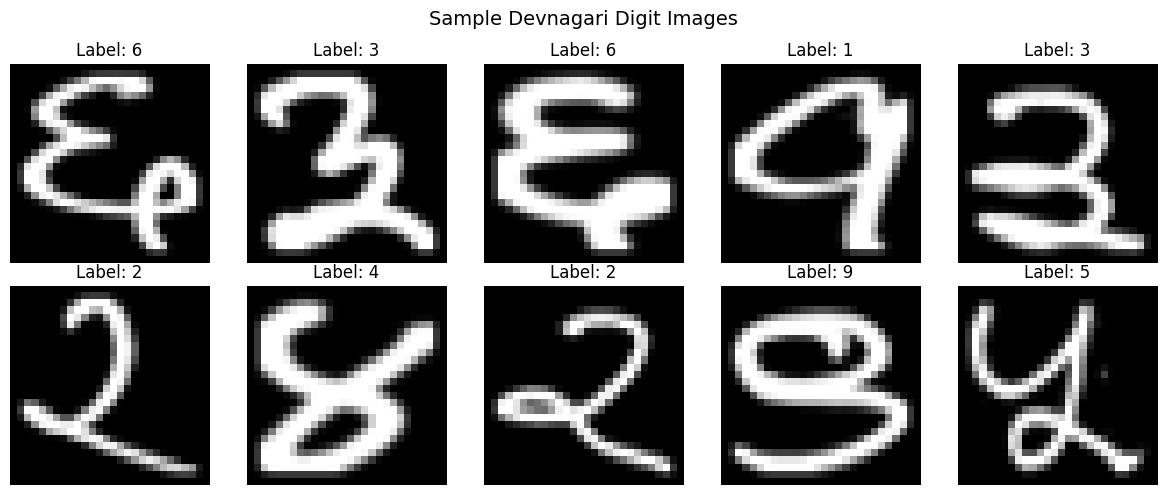

In [ ]:
# TASK 1: DATA PREPARATION
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Train/"
test_dir = "/content/drive/MyDrive/DevanagariHandwrittenDigitDataset/Test/"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_names = [c for c in class_names if os.path.isdir(os.path.join(folder, c))]
    class_map = {name: i for i, name in enumerate(class_names)}
    print(f"Class mapping: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {filename}: {e}")
    return np.array(images), np.array(labels)

print("Loading training data...")
x_train, y_train = load_images_from_folder(train_dir)
print(f"Training images loaded: {x_train.shape[0]}\n")

print("Loading testing data...")
x_test, y_test = load_images_from_folder(test_dir)
print(f"Testing images loaded: {x_test.shape[0]}\n")

x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

num_classes = 10
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

print(f"Training set: {x_train.shape}, Labels: {y_train_encoded.shape}")
print(f"Testing set:  {x_test.shape}, Labels: {y_test_encoded.shape}")

np.random.seed(42)
random_indices = np.random.choice(len(x_train), 10, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(random_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[idx]}")
    plt.axis('off')
plt.suptitle("Sample Devnagari Digit Images", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# TASK 2: BUILD THE FCN MODEL
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TASK 3: COMPILE THE MODEL
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


Epoch 1/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3021 - loss: 1.9749
Epoch 1: val_loss improved from None to 7.65224, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4976 - loss: 1.6006 - val_accuracy: 0.0000e+00 - val_loss: 7.6522
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8118 - loss: 0.6326
Epoch 2: val_loss did not improve from 7.65224
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8460 - loss: 0.5113 - val_accuracy: 0.0000e+00 - val_loss: 9.3532
Epoch 3/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9146 - loss: 0.3002
Epoch 3: val_loss did not improve from 7.65224
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9230 - loss: 0.2738 - val_accuracy: 0.0000e+00 - val_loss: 9.9072
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9464 - loss: 0.1990
Epoch 4: val_loss did not improve from 7.6522

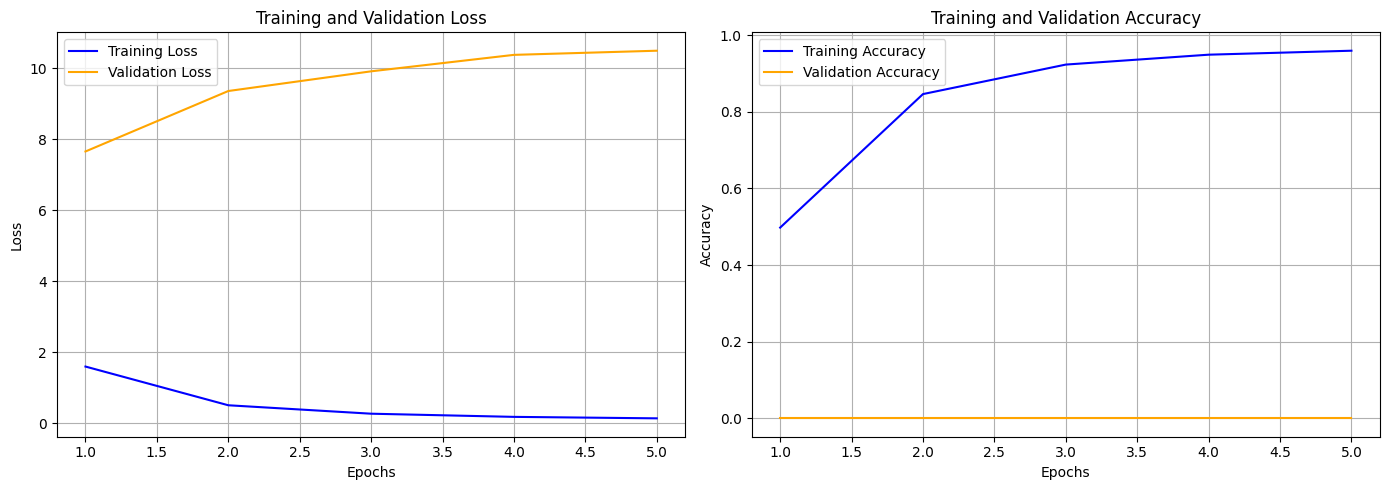

In [ ]:
# TASK 4: TRAIN THE MODEL
batch_size = 128
epochs = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        verbose=1,
        restore_best_weights=True
    )
]

history = model.fit(
    x_train,
    y_train_encoded,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# Plot training curves
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# TASK 5: EVALUATE THE MODEL
test_loss, test_acc = model.evaluate(x_test, y_test_encoded, verbose=2)

print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")

94/94 - 0s - 3ms/step - accuracy: 0.6197 - loss: 2.1483
Test Loss:     2.1483
Test Accuracy: 0.6197 (61.97%)


In [ ]:
# TASK 6: SAVE AND LOAD THE MODEL
model.save('devnagari_fcn_model.h5')
print("Model saved as 'devnagari_fcn_model.h5'")

loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully!")

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test_encoded, verbose=2)
print(f"Loaded Model - Test Loss:     {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_acc:.4f} ({loaded_acc * 100:.2f}%)")

Model saved as 'devnagari_fcn_model.h5'
Model loaded successfully!
94/94 - 1s - 6ms/step - accuracy: 0.6197 - loss: 2.1483
Loaded Model - Test Loss:     2.1483
Loaded Model - Test Accuracy: 0.6197 (61.97%)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted label for first image: 0
True label for first image:      0


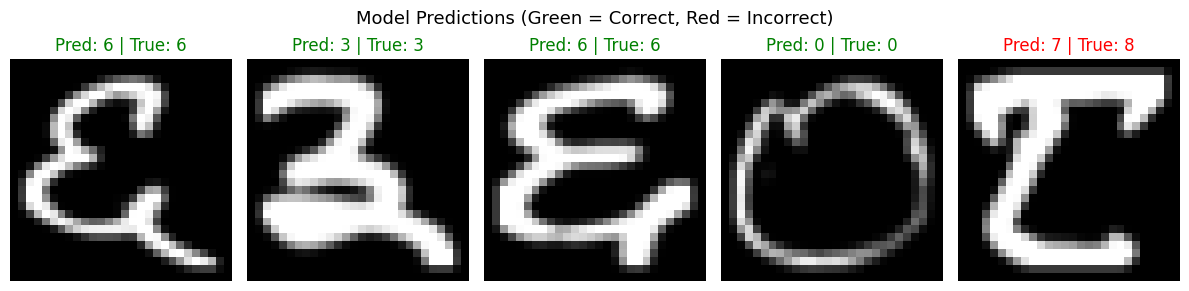


Total test images:      3000
Correctly classified:   1859
Incorrectly classified: 1141
Test Accuracy:          61.97%


In [ ]:
# TASK 7: MAKING PREDICTIONS
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_encoded, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image:      {np.argmax(y_test_encoded[0])}")

np.random.seed(42)
random_indices = np.random.choice(len(x_test), 5, replace=False)

plt.figure(figsize=(12, 3))
for i, idx in enumerate(random_indices):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    color = 'green' if predicted_labels[idx] == true_labels[idx] else 'red'
    plt.title(f"Pred: {predicted_labels[idx]} | True: {true_labels[idx]}", color=color)
    plt.axis('off')
plt.suptitle("Model Predictions (Green = Correct, Red = Incorrect)", fontsize=13)
plt.tight_layout()
plt.show()

correct = np.sum(predicted_labels == true_labels)
total = len(true_labels)
print(f"\nTotal test images:      {total}")
print(f"Correctly classified:   {correct}")
print(f"Incorrectly classified: {total - correct}")
print(f"Test Accuracy:          {correct / total * 100:.2f}%")